In [1]:
import sys
!{sys.executable} -m pip install tensorflow

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [3]:
 import sys
 print(sys.executable)

C:\Users\Hanumakshi\anaconda3\python.exe


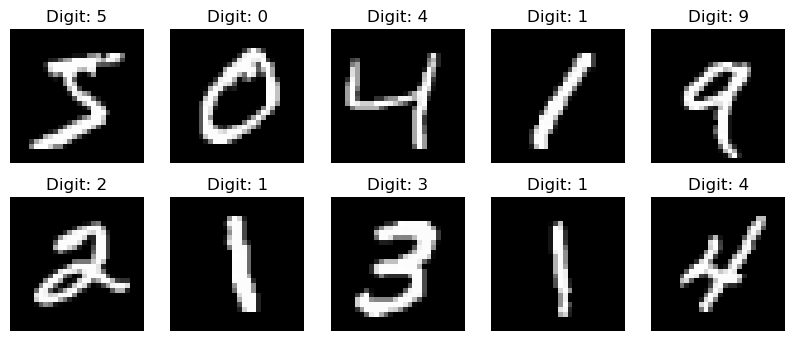

In [4]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Digit: " + str(y_train[i]))
    plt.axis('off')

plt.show()


In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\Hanumakshi\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9069 - loss: 0.3168 - val_accuracy: 0.9608 - val_loss: 0.1375
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9545 - loss: 0.1530 - val_accuracy: 0.9685 - val_loss: 0.1070
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9659 - loss: 0.1141 - val_accuracy: 0.9738 - val_loss: 0.0863
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9707 - loss: 0.0934 - val_accuracy: 0.9753 - val_loss: 0.0809
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9749 - loss: 0.0795 - val_accuracy: 0.9780 - val_loss: 0.0719


In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9749 - loss: 0.0796
Test Accuracy: 0.9749000072479248


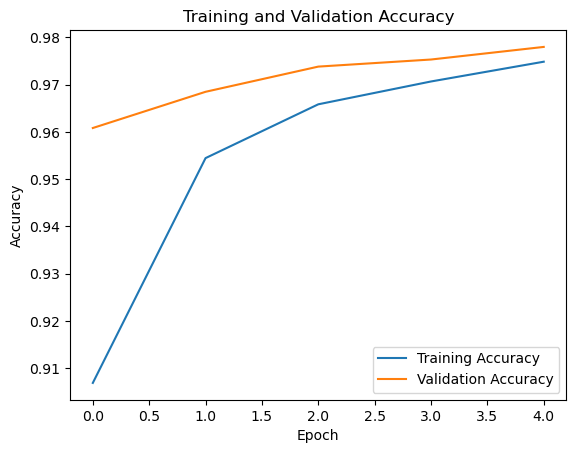

In [9]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

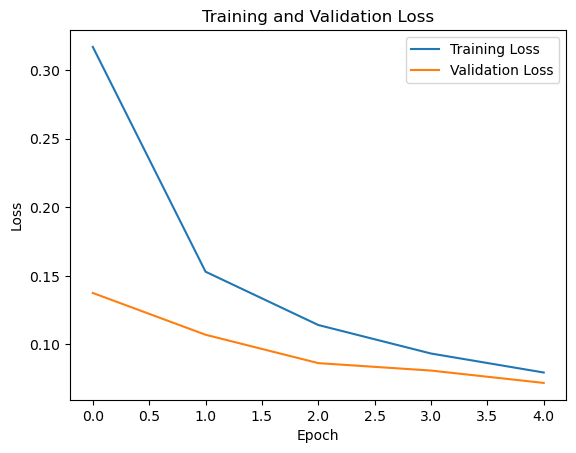

In [10]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [11]:
predictions = model.predict(X_test[:5])

predicted_labels = np.argmax(predictions, axis=1)

print("Actual labels:   ", y_test[:5])
print("Predicted labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Actual labels:    [7 2 1 0 4]
Predicted labels: [7 2 1 0 4]


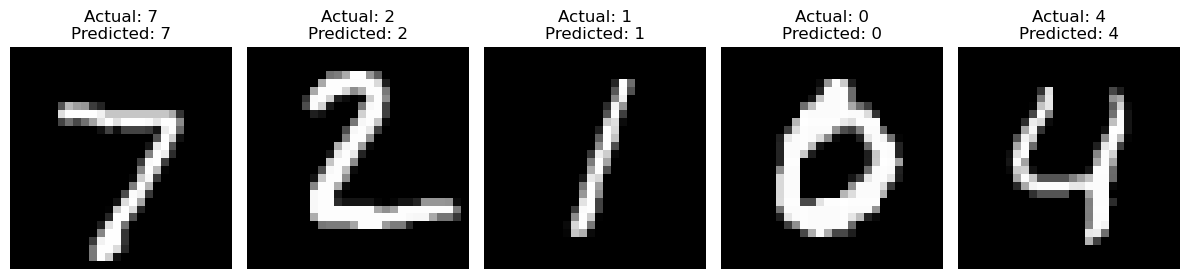

In [12]:
plt.figure(figsize=(12,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    
    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}"
    )
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8888 - loss: 0.3787 - val_accuracy: 0.9578 - val_loss: 0.1555
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9378 - loss: 0.2075 - val_accuracy: 0.9650 - val_loss: 0.1208
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9520 - loss: 0.1616 - val_accuracy: 0.9723 - val_loss: 0.1017
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9573 - loss: 0.1410 - val_accuracy: 0.9723 - val_loss: 0.0933
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9615 - loss: 0.1235 - val_accuracy: 0.9738 - val_loss: 0.0813


In [14]:
loss2, accuracy2 = model2.evaluate(X_test, y_test)

print("Original Model Accuracy:", test_accuracy)
print("New Model Accuracy:", accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9695 - loss: 0.0982
Original Model Accuracy: 0.9749000072479248
New Model Accuracy: 0.9695000052452087
